#### Hypothesis for KPI 2: Completion Time (Bryan)

To evaluate whether the new user interface improves efficiency, we test whether it reduces the time required for users to complete the process.

Null Hypothesis (H₀).
The new UI does not reduce completion time compared to the old design.

H0: μtest  ≥  μcontrol	​

Alternative Hypothesis (H₁).
The new UI reduces completion time compared to the old design.

H1: μtest  <  μcontrol

In [2]:
import pandas as pd
from Clean_Data import get_cleaned_vanguard_data

In [3]:
df = get_cleaned_vanguard_data(False)
#display(completed_df)

In [4]:
import pandas as pd
import numpy as np

def create_time_aware_behavior_report(df):
    
    df = df.copy()
    
    # 1. Clean datetime and sort chronologically
    df['date_time'] = pd.to_datetime(df['date_time'])
    df = df.sort_values(by=['client_id', 'visit_id', 'date_time'])
    
    step_map = {
        'start': 0,
        'step_1': 1,
        'step_2': 2,
        'step_3': 3,
        'confirm': 4
    }
    
    ideal_sequence = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

    # -------------------------------
    # PART 1: CLIENT JOURNEY CATEGORY
    # -------------------------------
    
    def classify_journey(group):
        steps = group['process_step'].tolist()
        step_nums = [step_map.get(s, -1) for s in steps]
        
        if steps == ideal_sequence:
            return 'perfect_path'
        
        for i in range(1, len(step_nums)):
            if step_nums[i] < step_nums[i-1]:
                return 'confused'
        
        if 'confirm' in steps:
            for i in range(1, len(step_nums)):
                if step_nums[i] > step_nums[i-1] + 1:
                    return 'skipped_steps'
            
            if steps[0] != 'start':
                return 'skipped_steps'
                
            return 'successful_with_repeats'
            
        return 'dropped_in_between'

    print("Analyzing chronological journeys...")
    
    classified_clients = (
        df.groupby('client_id')
        .apply(classify_journey)
        .reset_index()
    )
    
    classified_clients.columns = ['client_id', 'path_category']

    priority = {
        'perfect_path': 1,
        'successful_with_repeats': 2,
        'skipped_steps': 3,
        'confused': 4,
        'dropped_in_between': 5
    }
    
    classified_clients['priority'] = classified_clients['path_category'].map(priority)
    
    final_behavior = (
        classified_clients
        .sort_values('priority')
        .groupby('client_id')
        .first()
        .reset_index()
    )

    # Adjust column name if needed
    # variation_col = 'Variation' if 'Variation' in df.columns else 'variation'

    client_info = (
        df.groupby('client_id')
        .agg({
            'variation': 'first',
            'age': 'first',
            'gender': 'first',
            'tenure_years': 'first',
            'account_balance': 'first'
        })
        .reset_index()
    )

    client_level_df = final_behavior.merge(client_info, on='client_id', how='left')
    client_level_df = client_level_df.dropna(subset=['variation'])

    client_level_df = client_level_df[
        ['client_id', 'path_category', 'variation', 
         'age', 'gender', 'tenure_years', 'account_balance']
    ]

    # -------------------------------
    # PART 2: TIME SPENT ON EACH STEP
    # -------------------------------
    
    df['next_step'] = df.groupby(['client_id', 'visit_id'])['process_step'].shift(-1)
    df['next_time'] = df.groupby(['client_id', 'visit_id'])['date_time'].shift(-1)
    
    df['time_spent_seconds'] = (
        df['next_time'] - df['date_time']
    ).dt.total_seconds()
    
    # Keep only valid positive time differences
    time_step_df = df[
        (df['time_spent_seconds'] > 0) &
        (df['process_step'].notna()) &
        (df['next_step'].notna())
    ].copy()
    
    # Remove extreme outliers
    time_step_df = time_step_df[
        time_step_df['time_spent_seconds'] 
        < time_step_df['time_spent_seconds'].quantile(0.99)
    ]
    
    # Merging with path_categorie
    time_step_df = time_step_df.merge(
    client_level_df[['client_id', 'path_category']],
    on='client_id',
    how='left'
    )

    # Dropping missing values of variation
    time_step_df = time_step_df.dropna(subset=['variation'])

    # Focusing only on valid completed journeys + repeated journies
    avg_time_by_step = (
    time_step_df[time_step_df['path_category'].isin([
            'perfect_path', 'successful_with_repeats'])]
    .groupby(['variation', 'process_step'])['time_spent_seconds']
    .agg(['count', 'mean', 'median'])
    .reset_index()
    .sort_values(['variation', 'process_step']))

    time_step_df = time_step_df[
    [
        'client_id',
        'path_category',
        'variation',
        'time_spent_seconds',
        "process_step",
    ]]


    return client_level_df, avg_time_by_step, time_step_df, 


In [5]:
df2 = df
client_level_df, avg_time_by_step, time_step_df = create_time_aware_behavior_report(df2)

Analyzing chronological journeys...


In [6]:
time_step_df.info()

<class 'pandas.DataFrame'>
Index: 243145 entries, 4 to 339581
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   client_id           243145 non-null  int64  
 1   path_category       243145 non-null  str    
 2   variation           243145 non-null  str    
 3   time_spent_seconds  243145 non-null  float64
 4   process_step        243145 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 11.1 MB


### 1. Perfect path and success repetition

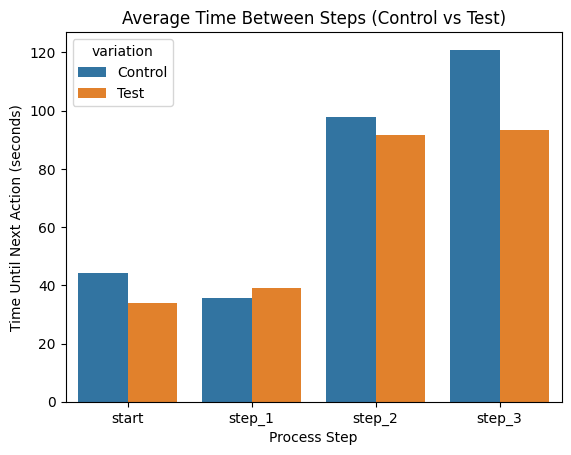

In [8]:
# Filter out 'confirm' ONLY for visualization
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = avg_time_by_step[avg_time_by_step['process_step'] != 'confirm']

step_order = ['start', 'step_1', 'step_2', 'step_3']

plt.figure()

sns.barplot(
    data=plot_df,
    x='process_step',
    y='mean',
    hue='variation',
    order=step_order
)

plt.title("Average Time Between Steps (Control vs Test)")
plt.xlabel("Process Step")
plt.ylabel("Time Until Next Action (seconds)")

plt.show()

### 2. Only for perfect path

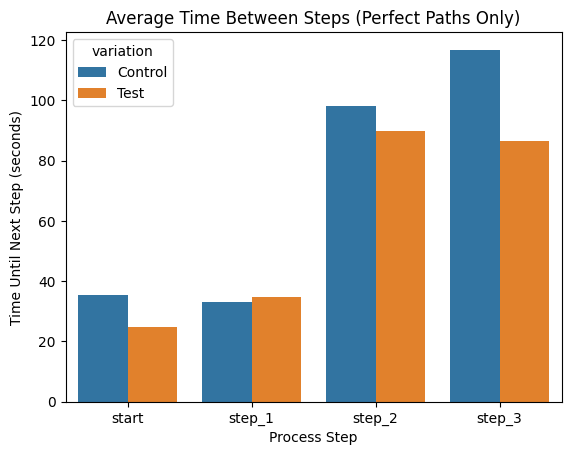

In [9]:
plot_df = time_step_df[
    (time_step_df['path_category'] == 'perfect_path') &
    (time_step_df['process_step'] != 'confirm')]

avg_time_perfect = (
    plot_df
    .groupby(['variation', 'process_step'])['time_spent_seconds']
    .mean()
    .reset_index())

step_order = ['start', 'step_1', 'step_2', 'step_3']

plt.figure()

sns.barplot(
    data=avg_time_perfect,
    x='process_step',
    y='time_spent_seconds',
    hue='variation',
    order=step_order)

plt.title("Average Time Between Steps (Perfect Paths Only)")
plt.xlabel("Process Step")
plt.ylabel("Time Until Next Step (seconds)")

plt.show()

In [10]:
avg_time_by_step

,variation,process_step,count,mean,median
0,Control,confirm,541,72.602588,26.0
1,Control,start,10281,44.233246,20.0
2,Control,step_1,9314,35.575370,21.0
3,Control,step_2,9433,97.845648,77.0
4,Control,step_3,9285,120.932795,76.0
5,Test,confirm,1496,130.921123,79.0
6,Test,start,12935,33.878701,11.0
7,Test,step_1,11393,39.178092,26.0
8,Test,step_2,11096,91.751442,70.0
9,Test,step_3,11098,93.483781,49.0


In [11]:
avg_time_perfect

,variation,process_step,time_spent_seconds
0,Control,start,35.574938
1,Control,step_1,33.153900
2,Control,step_2,98.227121
3,Control,step_3,116.845854
4,Test,start,24.771645
5,Test,step_1,34.848436
6,Test,step_2,89.952523
7,Test,step_3,86.460323


In this graph, we analyzed the time users take to move between steps in the process.
We filtered the data to include only users who followed a perfect path, meaning they completed all steps without confusion or repetition.
We also excluded the confirmation step because it doesn’t represent actual process time.
Then, we calculated the average time between steps and compared the Control group with the Test group to evaluate the impact of the new UI.”

or

“We measured the average time between steps only for users who followed a perfect journey, to isolate true process efficiency and compare Control vs Test.”

#### Insight: Hypotheisis “The new UI improves speed in later steps but introduces friction early in the process.”

H₀: μ_test ≥ μ_control  
H₁: μ_test < μ_control

In [12]:
means = (plot_df
    .groupby('variation')['time_spent_seconds']
    .agg(['count', 'mean', 'median'])
    .reset_index())

means

,variation,count,mean,median
0,Control,28777,70.885846,44.0
1,Test,32183,58.958394,34.0


The mean of the Test is lower compared to the control!

In [13]:
from scipy.stats import ttest_ind

control = plot_df[plot_df['variation'] == 'Control']['time_spent_seconds']
test = plot_df[plot_df['variation'] == 'Test']['time_spent_seconds']

t_stat, p_val = ttest_ind(test, control, alternative='less')

print(t_stat, p_val)

-16.989170518141687 6.959238669095974e-65


Interpretation: “The Test group has a significantly lower average time between steps compared to the Control group.”

#### Saving CVS for the Tablue

In [14]:
# Save average time by step summary
avg_time_perfect.to_csv("avg_time_perfect.csv", index=False)